In [ ]:
#import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,StandardScaler,MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report


In [ ]:
#Load Dataset
df=pd.read_csv("/content/pima-indians-diabetes.data.csv")
print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
df.shape

(768, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   times_pregnant            768 non-null    int64  
 1   glucose_concentration     768 non-null    int64  
 2   diastolic_blood_pressure  768 non-null    int64  
 3   triceps_sf_thickness      768 non-null    int64  
 4   serum_insulin             768 non-null    int64  
 5   bmi                       768 non-null    float64
 6   d_pedigree_function       768 non-null    float64
 7   years_of_age              768 non-null    int64  
 8   diabetes                  768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
df.describe()

,times_pregnant,glucose_concentration,diastolic_blood_pressure,triceps_sf_thickness,serum_insulin,bmi,d_pedigree_function,years_of_age,diabetes
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [ ]:
duplicate=df.duplicated()
print("No.of Duplicates: ",duplicate.sum())

No.of Duplicates:  0


In [ ]:
df.isnull().sum()

,0
times_pregnant,0
glucose_concentration,0
diastolic_blood_pressure,0
triceps_sf_thickness,0
serum_insulin,0
bmi,0
d_pedigree_function,0
years_of_age,0
diabetes,0


In [ ]:
df.head()

,times_pregnant,glucose_concentration,diastolic_blood_pressure,triceps_sf_thickness,serum_insulin,bmi,d_pedigree_function,years_of_age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
df.drop('times_pregnant',axis=1,inplace=True)

In [ ]:
df.head()

,glucose_concentration,diastolic_blood_pressure,triceps_sf_thickness,serum_insulin,bmi,d_pedigree_function,years_of_age,diabetes
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1


In [ ]:
#Outlier Detection
Q1 = df['glucose_concentration'].quantile(0.25)
Q3 = df['glucose_concentration'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Limit :",lower_bound)
print("Upper Limit :",upper_bound)


41.25
Lower Limit : 37.125
Upper Limit : 202.125


In [ ]:
df = df[(df['glucose_concentration'] >= lower_bound) & (df['glucose_concentration'] <= upper_bound)]
print(df.shape)

(571, 54)


In [ ]:
#Outlier Detection
Q1 = df['bmi'].quantile(0.25)
Q3 = df['bmi'].quantile(0.75)
IQR = Q3 - Q1
print(IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Lower Limit :",lower_bound)
print("Upper Limit :",upper_bound)


9.350000000000001
Lower Limit : 13.825
Upper Limit : 51.22500000000001


In [ ]:
df = df[(df['bmi'] >= lower_bound) & (df['bmi'] <= upper_bound)]
print(df.shape)

(557, 54)


In [ ]:
X = df.drop('diabetes', axis=1)
y = df['diabetes']

In [ ]:
#split the datset
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
scaler=MinMaxScaler()
cols_to_scale=['glucose_concentration','bmi']
x_train[cols_to_scale]=scaler.fit_transform(x_train[cols_to_scale])
x_test[cols_to_scale]=scaler.transform(x_test[cols_to_scale])
print(x_train.head())
print(x_test.head())

     glucose_concentration  ...  diastolic_blood_pressure_122
250               0.061856  ...                         False
129               0.051546  ...                         False
256               0.113402  ...                         False
207               0.639175  ...                         False
278               0.144330  ...                         False

[5 rows x 53 columns]
     glucose_concentration  ...  diastolic_blood_pressure_122
220               0.793814  ...                         False
630               0.144330  ...                         False
72                0.268041  ...                         False
327               0.814433  ...                         False
95                0.453608  ...                         False

[5 rows x 53 columns]


In [ ]:
#model building
model=LogisticRegression()
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
# Predictions
y_pred = model.predict(x_test)

In [ ]:
train_accuracy = model.score(x_train, y_train)
test_accuracy = model.score(x_test, y_test)
print("Training Accuracy:", train_accuracy)
print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.7370786516853932
Testing Accuracy: 0.6964285714285714


In [ ]:
#confusion Matrix
cm = confusion_matrix(y_test,y_pred)
print(cm)

[[43  9]
 [25 35]]


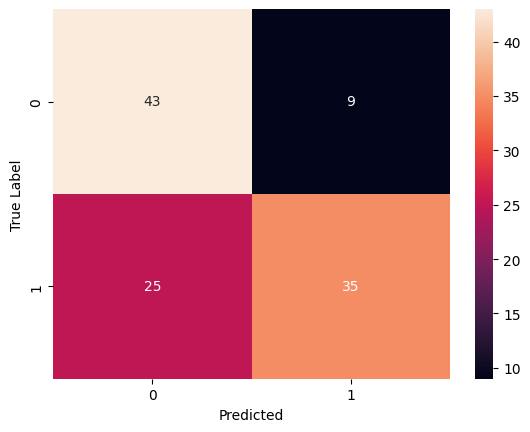

In [ ]:
#display  confusion matrix
sns.heatmap(cm,annot=True,fmt='d')
plt.xlabel('Predicted')
plt.ylabel('True Label')
plt.show()

In [ ]:
#print calssification Report
clss_report=classification_report(y_test,y_pred)
print(clss_report)

              precision    recall  f1-score   support

           0       0.63      0.83      0.72        52
           1       0.80      0.58      0.67        60

    accuracy                           0.70       112
   macro avg       0.71      0.71      0.69       112
weighted avg       0.72      0.70      0.69       112



In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

#auc_for_rus curve
fpr,tpr,thresholds=roc_curve(y_test,y_pred)
auc=roc_auc_score(y_test,y_pred)
print("AUC:",auc)

AUC: 0.7051282051282052


Text(0, 0.5, 'True Positive Rate')

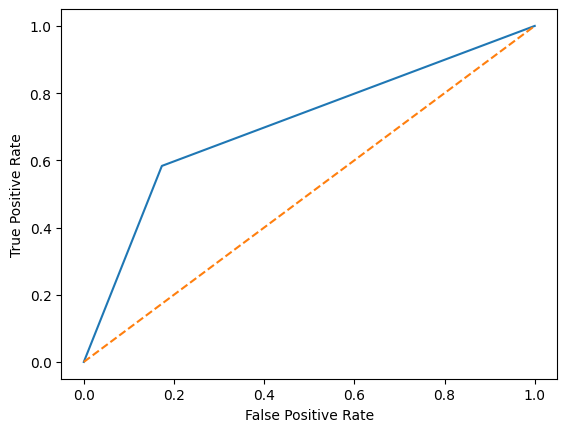

In [ ]:
#display auc_roc_curve
plt.plot(fpr,tpr,label='AUC={}'.format(auc))
plt.plot([0,1],[0,1],linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')